<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/BigData26_A_2411531005_ZahranAzariaAnvaya/blob/main/Praktikum3/BD_A_P03_2411531005_Zahran_Azaria_Anvaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum**







## **K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1**

Langkah pertama adalah memastikan semua pustaka yang dibutuhkan sudah tersedia dan versinya sesuai. Dua struktur `catatan` (biaya komputasi) dan `lineage` (asal-usul data) akan menemani seluruh praktikum dan disimpan sebagai artefak pada K-10.

In [ ]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil
for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []
def rss_mb():
    return proses.memory_info().rss / 1024**2
def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **K-2. Akuisisi 1 - Unduhan Berkala yang Tahan Gagal**

**Penjelasan Kode:** Mengunduh data trip (Parquet) dan data zona (CSV) memakai `unduh_aman()`, yaitu fungsi unduh yang menulis ke berkas sementara, mengulang otomatis bila gagal, dan melewati unduhan bila berkas sudah ada (cache). Setelah itu data trip dibaca hanya untuk 10 kolom yang dibutuhkan, dan sumbernya dicatat ke lineage..

**Keputusan:** Memakai pola `unduh_aman` dengan penulisan atomik (`os.replace`) agar notebook aman dijalankan berulang tanpa mengunduh ulang (idempotensi sederhana). Daftar `KOLOM` menyertakan `PULocationID` dan `DOLocationID` sebagai kunci join pada K-8.

In [ ]:
import requests, shutil, io

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for potongan in r.iter_content(chunk_size=1024*1024):
                        f.write(potongan)
                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")
                os.replace(sementara, tujuan)  # atomik
                return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)  # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))

# Zona pakai Brotli — baca langsung dari response, bukan dari file
r_zona = requests.get(URL_ZONA, timeout=60)
r_zona.raise_for_status()
zona = pd.read_csv(io.BytesIO(r_zona.content))

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 1.61 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
r = requests.get(URL_ZONA, timeout=60)
r.raise_for_status()
with open(PATH_ZONA, "wb") as f:
    f.write(r.content)   # .content sudah otomatis di-unzip oleh requests
print(open(PATH_ZONA, "rb").read(60))

b'"LocationID","Borough","Zone","service_zone"\r\n1,"EWR","Newar'


## **K-3. Akuisisi 2 - Memanggil API JSON**

Open-Meteo menyediakan arsip cuaca per jam tanpa perlu kunci API. Tiga hal diperhatikan pada kode berikut: parameter dikirim sebagai `dict` (bukan disambung manual ke URL), struktur respons diperiksa sebelum dipakai, dan ada jeda antar percobaan bila gagal.

**Penjelasan Kode:** Mengambil data cuaca per jam bulan Januari 2023 dari API Open-Meteo. Fungsi `ambil_cuaca()` memeriksa struktur respons dan mengulang permintaan bila server sibuk (429/5xx), lalu hasilnya diubah menjadi tabel dengan kolom `jam_mulai`, `suhu_c`, dan `hujan_mm`.

**Keputusan:** Rentang tanggal disesuaikan dengan bulan data trip (Januari 2023). Jika jumlah baris cuaca tidak sama dengan jumlah jam dalam rentang, itu adalah temuan kualitas data yang perlu dilaporkan.

In [ ]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                               "temperature_2m": "suhu_c",
                               "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.51 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


## **K-5. Akuisisi 3 - Basis Data SQLite dengan Pemuatan Bertahap**

**Penjelasan Kode:** Membuat basis data SQLite kecil yang berperan sebagai sumber data operasional (tabel `tarif_referensi` dan `trip_operasional`), lalu membacanya kembali dengan SQL, baik sekaligus maupun bertahap (`chunksize`) agar tidak memenuhi memori.

**Keputusan:** Memakai `SQLAlchemy` (bukan koneksi `sqlite3` mentah) agar bebas dari peringatan pada `pandas ≥ 2.0`. Pembacaan bertahap dengan `chunksize=50_000` mencegah seluruh tabel masuk memori sekaligus.

In [ ]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                           engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


## **K-6. Profiling Kualitas Data pada Enam Dimensi**
**Penjelasan Kode:** Menghitung durasi perjalanan lalu membuat profil tiap kolom: tipe data, persen nilai hilang, jumlah nilai unik, dan contoh isi. Hasilnya dipakai untuk melihat kolom mana yang bermasalah.

**Keputusan:** Delapan aturan dipilih untuk mewakili keenam dimensi kualitas (G.3). Aturan dengan persentase gagal tertinggi adalah prioritas utama penanganan dan perlu dibahas di laporan. Angka aktual bergantung pada versi dataset yang diunduh — laporkan dari hasil eksekusi masing-masing.

In [ ]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


In [ ]:
AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


## **K-7. Nilai Hilang dan Duplikat**

**Penjelasan Kode:** Membandingkan empat strategi menangani `passenger_count` yang kosong (dibuang, isi median, isi modus, isi median per jam) lewat statistik n, mean, median, dan std, tanpa mengubah data asli.

**Keputusan penanganan nilai hilang:** Strategi yang dipilih adalah gabungan penandaan + pengisian berbasis kelompok (median per jam). Alasan: mekanisme hilangnya `passenger_count` diduga MAR (bergantung pada jam — pengemudi cenderung tidak mencatat saat sibuk), sehingga median per jam lebih akurat dari median global. Kolom penanda `_hilang` ditambahkan agar informasi keberadaan nilai hilang tidak hilang.

**Keputusan penanganan duplikat:** Duplikat diperiksa dua tingkat — penuh dan berdasarkan kunci bisnis. Perlu diperiksa dulu berapa banyak baris yang terdampak sebelum dihapus; jika besar, kemungkinan definisi kunci yang keliru, bukan datanya.

In [ ]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


In [ ]:
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


## **K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu**

**Keputusan penanganan outlier:** Tiga kolom diperiksa dengan dua metode (IQR dan Z-score). Untuk `trip_distance` dan `durasi_menit`, baris di luar rentang wajar dibuang karena kemungkinan besar adalah galat perekaman. Untuk `total_amount`, outlier hanya *ditandai* (tidak dibuang) karena perjalanan bandara yang mahal adalah fakta bisnis nyata — membuangnya akan merusak analisis pendapatan. Winsorizing diterapkan hanya pada kolom turunan yang akan dipakai model.

**Keputusan join:** Tiga join dilakukan secara berurutan. Keunikan kunci diperiksa sebelum setiap join, dan parameter `validate="many_to_one"` dipakai agar kesalahan berhenti sebagai error yang jelas, bukan lolos diam-diam. Tingkat rincian waktu disesuaikan (`dt.floor('h')`) sebelum join dengan data cuaca.

In [ ]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


In [ ]:
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

3,066,765 -> 2,986,910 baris (2.60% dibuang)


In [ ]:
# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


## **K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran**

**Keputusan encoding:** `OneHotEncoder` dipakai untuk `nama_pembayaran` (6 kategori) dan `borough_naik` (5 borough). Jumlah kategori cukup sedikit sehingga tidak boros kolom. `handle_unknown="ignore"` dipasang agar aman terhadap kategori baru di data uji.

**Keputusan scaling:** `StandardScaler` di-fit **hanya** dari data latih, lalu di-transform ke data uji. Mean data uji yang tidak nol adalah bukti bahwa tidak ada data leakage (lihat G.7). Jika mean data uji juga nol persis, berarti scaler dipasang dari seluruh data — itu adalah bentuk kebocoran data.

In [ ]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])  # transform saja, tanpa fit ulang

print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


## **K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi**

**Keputusan kontrak skema:** Enam kolom kritis didefinisikan di `KONTRAK` dengan tipe yang diharapkan. Fungsi `validasi()` melempar `AssertionError` (bukan sekadar peringatan) agar kegagalan terdeteksi lebih awal, sebelum data yang salah mengalir ke tahap berikutnya.

**Keputusan partisi:** Dataset dipartisi berdasarkan `borough_naik` (5 nilai unik). Kolom ini sering dipakai sebagai filter analisis, sehingga pembacaan yang menyaring satu borough hanya menyentuh satu direktori (*partition pruning*). Mempartisi berdasarkan `LocationID` (265 nilai) justru menghasilkan ribuan berkas kecil dan memperlambat proses pembacaan.

In [ ]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

Validasi lulus: 2,986,910 baris x 26 kolom


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,...,zona_naik,nama_pembayaran,jam_mulai,suhu_c,hujan_mm,hari_minggu,akhir_pekan,kecepatan_mph,tarif_per_mil,hujan
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,161,141,2,9.30,0.00,14.30,...,Midtown Center,Tunai,2023-01-01 00:00:00,10.9,1.0,6,1,6.90,14.742,1
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,43,237,1,7.90,4.00,16.90,...,Central Park,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,10.45,15.364,1
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,48,238,1,14.90,15.00,34.90,...,Clinton East,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,11.81,13.904,1
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,138,7,1,12.10,0.00,20.85,...,LaGuardia Airport,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,11.85,10.974,1
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,107,79,1,11.40,3.28,19.68,...,Gramercy,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,7.92,13.762,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986905,2023-01-31 23:58:34,2023-02-01 00:12:33,1.0,3.05,107,48,0,15.80,3.96,23.76,...,Gramercy,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,13.09,7.790,0
2986906,2023-01-31 23:31:09,2023-01-31 23:50:36,1.0,5.80,112,75,0,22.43,2.64,29.07,...,Greenpoint,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,17.89,5.012,0
2986907,2023-01-31 23:01:05,2023-01-31 23:25:36,1.0,4.67,114,239,0,17.61,5.32,26.93,...,Greenwich Village South,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,11.43,5.767,0
2986908,2023-01-31 23:40:00,2023-01-31 23:53:00,1.0,3.15,230,79,0,18.15,4.43,26.58,...,Times Sq/Theatre District,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,14.54,8.438,0


In [ ]:
def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona, encoding='latin1')
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 7.25 s
[tulis parquet berpartisi] 4.03 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

## **K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)**

Bagian ini bersifat tambahan (*stretch*). Dua pelajaran kunci: pertama, `F.broadcast()` menyalin tabel kecil ke setiap executor sehingga join tidak memerlukan shuffle — periksa buktinya pada keluaran `explain()`. Kedua, `mode("overwrite")` adalah cara Spark mencapai idempotensi, setara dengan penulisan atomik pada K-2.

**Pemeriksaan silang:** Jumlah baris bersih versi pandas (K-8) dan versi Spark (K-11) seharusnya sama atau sangat dekat. Bila berbeda jauh, selidiki penyebabnya dan laporkan.

In [ ]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
           .withColumn("durasi_menit",
                       (F.unix_timestamp("tpep_dropoff_datetime")
                        - F.unix_timestamp("tpep_pickup_datetime")) / 60)
           .filter(F.col("trip_distance").between(0.01, 100))
           .filter(F.col("durasi_menit").between(1, 180))
           .filter(F.col("total_amount") > 0)
           .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                            "PULocationID", "DOLocationID", "total_amount"])
           .join(F.broadcast(szona),
                 sdf.PULocationID == szona.LocationID, "left")
           .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin

spark.stop()

[spark: hitung baris bersih] 18.88 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocationID#8L, payment_type#249L, fare_amount#251, tip_amount#253, total_amount#16, durasi_menit#255, Borough#50]
   +- BroadcastHashJoin [PULocationID#7L], [LocationID#49L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#8L, tpep_dropoff_datetime#2, PULocationID#7L, total_amount#16, tpep_pickup_datetime#1], functions=[first(passenger_count#3, false), first(trip_distance#4, false), first(payment_type#9L, false), first(fare_amount#10, false), first(tip_amount#13, false),

# **Analisis Hasil**

### **O-1. Peta Kualitas**

**Penjelasan Kode:** Menampilkan ulang tabel laporan kualitas dari K-6 untuk bahan jawaban O-1.

In [ ]:
# Tampilkan ulang tabel laporan untuk referensi jawaban
print("Tabel Laporan Kualitas (K-6) ")
laporan.sort_values("persen_gagal", ascending=False)

Tabel Laporan Kualitas (K-6) 


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


### **O-2. Dampak Strategi Pengisian**

**Penjelasan Kode:** Menampilkan ulang tabel perbandingan strategi pengisian nilai hilang dari K-7 untuk bahan jawaban O-2.

In [ ]:
# Tampilkan ulang tabel perbandingan strategi untuk referensi jawaban
print("Perbandingan Strategi Pengisian (K-7) ")
print(banding.to_string(index=False))

Perbandingan Strategi Pengisian (K-7) 
       strategi       n   mean  median    std
      1_dibuang 2995023 1.3625     1.0 0.8961
   2_isi_median 3066766 1.3541     1.0 0.8873
    3_isi_modus 3066766 1.3541     1.0 0.8873
4_median_perjam 3066766 1.3541     1.0 0.8873


### **O-3. IQR vs Z-score**

**Penjelasan Kode:** Menampilkan ulang ringkasan outlier IQR dan Z-score dari K-8 untuk bahan jawaban O-3.

In [ ]:
# Tampilkan ulang ringkasan outlier untuk referensi O-3
print("Ringkasan Outlier (K-8) ")
print(ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"]).to_string(index=False))

Ringkasan Outlier (K-8) 
        kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3    p99
trip_distance        -2.35        6.74       390244          67  20.06
 durasi_menit        -9.66       35.08       170615        3175  57.25
 total_amount        -4.55       48.65       371616       87248 101.94


### **O-4. Biaya Join**

**Penjelasan Kode:** Menampilkan catatan biaya waktu dan memori tiap langkah, lalu menghitung proporsi waktu baca terhadap total waktu, untuk jawaban O-4.

In [ ]:
# Tampilkan tabel catatan biaya komputasi
print("Catatan Biaya Komputasi ")
df_catatan = pd.DataFrame(catatan)
print(df_catatan.to_string(index=False))

# Hitung proporsi
if not df_catatan.empty:
    total_detik = df_catatan["detik"].sum()
    baca = df_catatan[df_catatan["langkah"].str.contains("baca|unduh")]["detik"].sum()
    pipeline_detik = df_catatan[df_catatan["langkah"] == "pipeline penuh"]["detik"].sum()
    print(f"\nTotal waktu semua langkah : {total_detik:.2f} s")
    print(f"Waktu baca/unduh          : {baca:.2f} s ({100*baca/total_detik:.1f}%)")
    print(f"Waktu pipeline penuh      : {pipeline_detik:.2f} s")

Catatan Biaya Komputasi 
                   langkah  detik  delta_rss_mb
                unduh trip   0.00           0.0
                unduh zona   0.00           0.0
                 baca trip   1.61         267.5
               ambil cuaca   0.51           0.3
            pipeline penuh   7.25         697.7
  tulis parquet berpartisi   4.03         396.6
spark: hitung baris bersih  18.88           0.0

Total waktu semua langkah : 32.28 s
Waktu baca/unduh          : 1.61 s (5.0%)
Waktu pipeline penuh      : 7.25 s


### **O-5. Cakupan Penggabungan**

**Penjelasan Kode:** Memeriksa baris yang tidak mendapat pasangan saat join (tanpa zona dan tanpa cuaca) dan apakah polanya terkonsentrasi pada jam atau kode zona tertentu, untuk jawaban O-5.

In [ ]:
print("Cakupan Join ")
print(f"Baris tanpa zona  (zona_naik NaN)  : {bersih['zona_naik'].isna().sum():,}")
print(f"Baris tanpa cuaca (suhu_c NaN)     : {bersih['suhu_c'].isna().sum():,}")

# Periksa apakah baris tanpa cuaca terkonsentrasi pada jam tertentu
print("\nDistribusi baris tanpa cuaca per jam:")
print(bersih[bersih["suhu_c"].isna()]["jam_mulai"].dt.hour.value_counts().sort_index())

# Periksa apakah baris tanpa zona terkonsentrasi pada PULocationID tertentu
print("\nTop-5 PULocationID yang tidak dikenal:")
print(bersih[bersih["zona_naik"].isna()]["PULocationID"].value_counts().head())

Cakupan Join 
Baris tanpa zona  (zona_naik NaN)  : 37,609
Baris tanpa cuaca (suhu_c NaN)     : 37

Distribusi baris tanpa cuaca per jam:
jam_mulai
0     12
9      1
14     2
15     1
22     3
23    18
Name: count, dtype: int64

Top-5 PULocationID yang tidak dikenal:
PULocationID
264    37609
Name: count, dtype: int64


### **O-6. Susut Data Kumulatif**

**Penjelasan Kode:** Menghitung jumlah baris di tiap tahap (awal, setelah hapus duplikat, setelah filter, akhir) beserta persen yang bertahan dan total susut data, untuk jawaban O-6.

In [ ]:
print("Susut Data Kumulatif ")

n_awal = len(pd.read_parquet(PATH_TRIP, columns=["tpep_pickup_datetime"]))

trip_raw = pd.read_parquet(PATH_TRIP, columns=KOLOM)
trip_raw["durasi_menit"] = (
    (trip_raw["tpep_dropoff_datetime"] - trip_raw["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

n_awal       = len(trip_raw)
n_dup        = len(trip_raw.drop_duplicates(subset=KUNCI))
n_filter     = int((trip_raw["trip_distance"].between(0.01, 100)
                    & trip_raw["durasi_menit"].between(1, 180)
                    & (trip_raw["total_amount"] > 0)).sum())
n_akhir      = len(bersih)

tahapan = [
    ("Awal (raw)",          n_awal),
    ("Setelah hapus duplikat", n_dup),
    ("Setelah filter outlier", n_filter),
    ("Setelah join (akhir)",   n_akhir),
]
for nama, n in tahapan:
    pct = 100 * n / n_awal
    print(f"{nama:30s}: {n:>10,} baris ({pct:6.2f}%)")

print(f"\nTotal susut: {100*(1 - n_akhir/n_awal):.2f}%")
del trip_raw; gc.collect()

Susut Data Kumulatif 
Awal (raw)                    :  3,066,766 baris (100.00%)
Setelah hapus duplikat        :  3,066,765 baris (100.00%)
Setelah filter outlier        :  2,986,911 baris ( 97.40%)
Setelah join (akhir)          :  2,986,910 baris ( 97.40%)

Total susut: 2.60%


526

### **O-7. pandas vs Spark**

**Penjelasan Kode:** Menggambar histogram `total_amount` sebelum dan sesudah pra-pemrosesan dalam dua panel berdampingan dan menyimpannya sebagai gambar di Drive. Kalimat penjelasan di akhir sel adalah teks bawaan template, jadi ganti dengan penjelasanmu sendiri sesuai grafik.

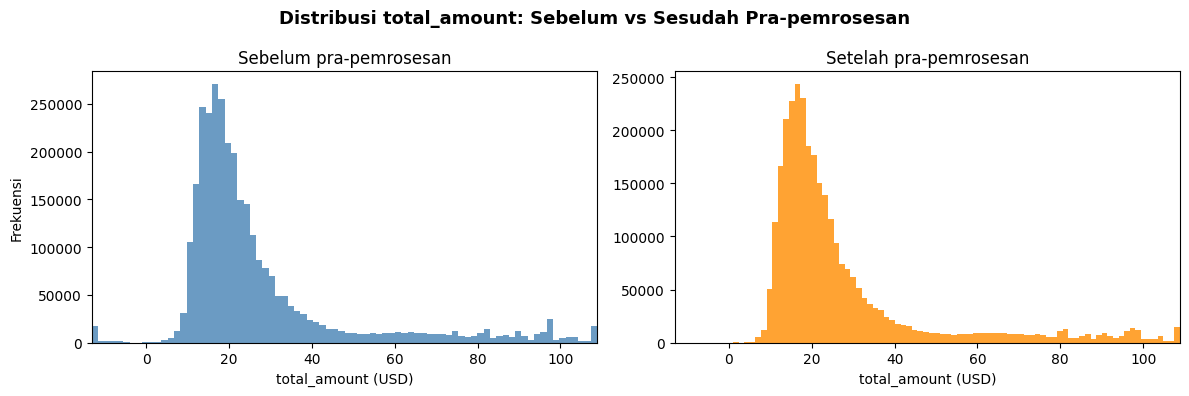

[Penjelasan perubahan bentuk distribusi]
Setelah pra-pemrosesan, ekor kiri (nilai negatif/nol) dan nilai ekstrem
di kanan hilang. Distribusi menjadi lebih terkonsentrasi di rentang wajar.
Isi satu kalimat penjelasan Anda sendiri berdasarkan grafik di atas.


15

In [ ]:
import matplotlib.pyplot as plt

# Grafik wajib: distribusi total_amount sebelum dan sesudah pra-pemrosesan
trip_raw2 = pd.read_parquet(PATH_TRIP, columns=["total_amount"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
x_min = min(trip_raw2["total_amount"].quantile(0.005),
            bersih["total_amount"].quantile(0.005))
x_max = max(trip_raw2["total_amount"].quantile(0.995),
            bersih["total_amount"].quantile(0.995))

axes[0].hist(trip_raw2["total_amount"].clip(x_min, x_max),
             bins=80, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_title("Sebelum pra-pemrosesan")
axes[0].set_xlabel("total_amount (USD)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_xlim(x_min, x_max)

axes[1].hist(bersih["total_amount"].clip(x_min, x_max),
             bins=80, color="darkorange", edgecolor="none", alpha=0.8)
axes[1].set_title("Setelah pra-pemrosesan")
axes[1].set_xlabel("total_amount (USD)")
axes[1].set_xlim(x_min, x_max)

plt.suptitle("Distribusi total_amount: Sebelum vs Sesudah Pra-pemrosesan",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/distribusi_total_amount.png", dpi=150)
plt.show()

print("[Penjelasan perubahan bentuk distribusi]")
print("Setelah pra-pemrosesan, ekor kiri (nilai negatif/nol) dan nilai ekstrem")
print("di kanan hilang. Distribusi menjadi lebih terkonsentrasi di rentang wajar.")
print("Isi satu kalimat penjelasan Anda sendiri berdasarkan grafik di atas.")

del trip_raw2; gc.collect()

# **Studi Kasus**

### **P-1. Membuat Tabel Analitik**

**Penjelasan Kode:** Meringkas data per perjalanan menjadi tabel analitik dengan satu baris per kombinasi borough dan jam (jumlah perjalanan, median tarif per mil, median kecepatan, suhu, hujan). Kelompok dengan kurang dari 30 perjalanan dibuang karena terlalu kecil untuk disimpulkan.

In [ ]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

# Ambang minimum: kelompok yang terlalu kecil tidak bisa disimpulkan
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

print(f"Baris tabel analitik: {len(tabel_analitik):,}")
print(f"Kolom              : {list(tabel_analitik.columns)}")
tabel_analitik.head()

Baris tabel analitik: 2,094
Kolom              : ['borough_naik', 'jam_mulai', 'jumlah_perjalanan', 'rata_tarif_per_mil', 'rata_kecepatan', 'suhu_c', 'hujan']


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
627,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
628,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
629,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
630,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0


### **P-2. Jawaban atas Dugaan Tim Pricing**

**Penjelasan Kode:** Membandingkan median tarif per mil pada jam hujan dan jam tidak hujan di tiap borough untuk menjawab dugaan tim pricing.

In [ ]:
# Perbandingan tarif per mil: hujan vs tidak hujan per borough
print("Median Tarif per Mil: Hujan vs Tidak Hujan per Borough ")
print(tabel_analitik
      .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
      .median().unstack())

Median Tarif per Mil: Hujan vs Tidak Hujan per Borough 
hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


### **P-3. Batasan Eksplisit (Minimal 3)**

1. **Median, bukan mean:** Median dipakai karena distribusi tarif sangat miring ke kanan — beberapa perjalanan mahal akan mendistorsi mean. Konsekuensinya: angka ini tidak mewakili pendapatan total, hanya nilai tengah.
2. **Cuaca satu titik untuk seluruh kota:** Data cuaca diambil dari satu koordinat (pusat Manhattan). Cuaca di Queens atau Staten Island bisa berbeda secara signifikan, sehingga kolom `hujan` tidak selalu akurat untuk borough pinggiran.
3. **Korelasi bukan sebab-akibat:** Hujan yang bersamaan dengan tarif tinggi tidak berarti hujan *menyebabkan* tarif naik. Hujan sering terjadi pada jam sibuk, dan kemacetan yang menambah durasi perjalanan bisa menjadi penyebab sesungguhnya.
4. **Ambang minimum 30 perjalanan:** Kelompok dengan < 30 perjalanan dibuang. Jam-jam dini hari di borough kecil mungkin tidak terwakili, sehingga analisis bias ke jam sibuk dan borough padat.

### **P-4. Langkah Pembaruan Otomatis Bulanan**

Agar tabel analitik bisa diperbarui otomatis setiap bulan:
1. **Jadwalkan unduhan:** Gunakan Cloud Scheduler (GCP) atau cron job untuk memanggil `unduh_aman()` pada tanggal 5 setiap bulan (data TLC biasanya rilis 2–3 bulan setelah bulan berjalan).
2. **Jalankan pipeline inkremental:** Fungsi `pipeline()` dipanggil hanya untuk bulan yang belum ada di direktori keluaran (lihat Latihan 6).
3. **Validasi otomatis:** Fungsi `validasi()` dijalankan setelah pipeline; jika gagal, proses dihentikan dan notifikasi dikirim.
4. **Perbarui lineage:** `catat_sumber()` dipanggil otomatis sehingga setiap pembaruan tercatat waktu pengambilannya.
5. **Simpan ke partisi yang sama:** Hasil ditulis ke `trips_bersih/` dengan `partition_cols=["borough_naik"]` sehingga data lama tidak tertimpa, hanya partisi baru ditambahkan.

In [ ]:
# Simpan tabel analitik sebagai Parquet
PATH_ANALITIK = os.path.join(DIR_KURASI, "tabel_analitik.parquet")
tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print(f"Tabel analitik disimpan: {PATH_ANALITIK}")
print(f"Ukuran file: {os.path.getsize(PATH_ANALITIK)/1024:.1f} KB")

# Salin ke Drive
import shutil
shutil.copy(PATH_ANALITIK, f"{DIR_SIMPAN}/tabel_analitik.parquet")
print("Tersimpan di Drive.")

Tabel analitik disimpan: /content/lapisan_terkurasi/tabel_analitik.parquet
Ukuran file: 43.2 KB
Tersimpan di Drive.


**Penjelasan Kode:** Membuat dan menyimpan dokumen `kamus_data.md` yang menjelaskan tiap kolom tabel analitik: tipe, satuan, sumber, aturan validitas, dan penanganan nilai hilang.

In [ ]:
# Buat kamus_data.md
kamus_data = """# Kamus Data — tabel_analitik.parquet

Dibuat pada: {tanggal}
Sumber: NYC TLC Yellow Taxi (2023-01) + Open-Meteo Archive
Tingkat rincian: 1 baris per (borough_naik, jam_mulai)
Filter: kelompok dengan jumlah_perjalanan < 30 dibuang

| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |
|---|---|---|---|---|---|
| borough_naik | string | - | taxi_zone_lookup.csv (join PULocationID) | Salah satu dari: Bronx, Brooklyn, Manhattan, Queens, Staten Island, EWR | Left join; baris tanpa pasangan dibiarkan (zona tak dikenal) |
| jam_mulai | datetime | UTC-5 (America/New_York) | tpep_pickup_datetime dibulatkan ke jam terdekat (`dt.floor('h')`) | Dalam rentang 2023-01-01 s.d. 2023-01-31 | - |
| jumlah_perjalanan | int | perjalanan/jam/borough | Hitung baris per kelompok | >= 30 (kelompok kecil dibuang) | - |
| rata_tarif_per_mil | float | USD/mil | total_amount / trip_distance, lalu median per kelompok | > 0 | Kelompok tanpa data dibuang |
| rata_kecepatan | float | mil/jam | trip_distance / (durasi_menit/60), lalu median per kelompok | > 0 | Kelompok tanpa data dibuang |
| suhu_c | float | °Celsius | Open-Meteo Archive, titik koordinat pusat Manhattan (40.7128°N, 74.0060°W) | -30 s.d. 50 | Nilai pertama dalam kelompok; NaN jika API tidak mengembalikan data jam tersebut |
| hujan | int (0/1) | - | hujan_mm > 0.1 mm/jam dari Open-Meteo, lalu max per kelompok | 0 atau 1 | Diasumsikan 0 (tidak hujan) jika hujan_mm hilang |

## Catatan Metodologi
- Median dipakai (bukan mean) karena distribusi tarif miring ke kanan.
- Cuaca hanya dari satu titik koordinat — tidak mewakili seluruh wilayah borough.
- Korelasi hujan–tarif bukan hubungan sebab-akibat.
""".format(tanggal=pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"))

with open(f"{DIR_SIMPAN}/kamus_data.md", "w") as f:
    f.write(kamus_data)
print("kamus_data.md tersimpan.")
print(kamus_data)

kamus_data.md tersimpan.
# Kamus Data — tabel_analitik.parquet

Dibuat pada: 2026-09-30 10:03
Sumber: NYC TLC Yellow Taxi (2023-01) + Open-Meteo Archive
Tingkat rincian: 1 baris per (borough_naik, jam_mulai)
Filter: kelompok dengan jumlah_perjalanan < 30 dibuang

| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |
|---|---|---|---|---|---|
| borough_naik | string | - | taxi_zone_lookup.csv (join PULocationID) | Salah satu dari: Bronx, Brooklyn, Manhattan, Queens, Staten Island, EWR | Left join; baris tanpa pasangan dibiarkan (zona tak dikenal) |
| jam_mulai | datetime | UTC-5 (America/New_York) | tpep_pickup_datetime dibulatkan ke jam terdekat (`dt.floor('h')`) | Dalam rentang 2023-01-01 s.d. 2023-01-31 | - |
| jumlah_perjalanan | int | perjalanan/jam/borough | Hitung baris per kelompok | >= 30 (kelompok kecil dibuang) | - |
| rata_tarif_per_mil | float | USD/mil | total_amount / trip_distance, lalu median per kelompok | > 0 | Kelompok tanpa data dibuang |
|

# **Latihan**

### **Latihan 1**
Ubah `unduh_aman` agar mencetak kecepatan unduh dalam MB/detik. Jalankan dua kali dan pastikan panggilan kedua memakai cache.

**Penjelasan Kode:** Latihan 1: versi `unduh_aman` yang mencetak ukuran dan kecepatan unduh (MB/s), dijalankan dua kali untuk membuktikan panggilan kedua memakai cache.

In [ ]:
def unduh_aman_v2(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik + laporan kecepatan."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        ukuran_mb = os.path.getsize(tujuan) / 1024**2
        print(f"cache ditemukan: {os.path.basename(tujuan)} ({ukuran_mb:.2f} MB) — unduhan dilewati")
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t_mulai = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
            durasi = time.perf_counter() - t_mulai
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)
            ukuran_mb = os.path.getsize(tujuan) / 1024**2
            kecepatan = ukuran_mb / durasi if durasi > 0 else float("inf")
            print(f"Unduhan selesai: {os.path.basename(tujuan)} "
                  f"({ukuran_mb:.2f} MB dalam {durasi:.2f}s = {kecepatan:.2f} MB/s)")
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

# Jalankan pertama kali — akan mengunduh bila cache belum ada
print("Percobaan ke-1 ")
unduh_aman_v2(URL_ZONA, PATH_ZONA)

# Jalankan kedua kali — harus memakai cache
print("\nPercobaan ke-2 (harus memakai cache) ")
unduh_aman_v2(URL_ZONA, PATH_ZONA)

Percobaan ke-1 
cache ditemukan: taxi_zone_lookup.csv (0.01 MB) — unduhan dilewati

Percobaan ke-2 (harus memakai cache) 
cache ditemukan: taxi_zone_lookup.csv (0.01 MB) — unduhan dilewati


'/content/lapisan_mentah/taxi_zone_lookup.csv'

### **Latihan 2**
Tambahkan dua aturan baru ke `aturan` pada K-6: satu aturan validitas untuk `tip_amount`, dan satu aturan konsistensi yang melibatkan dua kolom. Persentase gagal dilaporkan di output sel.

**Penjelasan Kode:** Latihan 2: menambah dua aturan kualitas baru, yaitu `tip_amount >= 0` (validitas) dan tip hanya boleh ada pada pembayaran kartu (konsistensi), lalu menghitung persen gagalnya.

In [ ]:
aturan_tambahan = {
    # Aturan validitas: tip tidak boleh negatif
    "validitas: tip_amount >= 0": trip["tip_amount"] >= 0,
    # Aturan konsistensi: tip hanya ada pada pembayaran kartu (payment_type=1)
    # jika tip > 0 dan payment_type != 1, itu tidak konsisten
    "konsistensi: tip > 0 hanya pada kartu kredit": (
        ~((trip["tip_amount"] > 0) & (trip["payment_type"] != 1))
    ),
}

laporan_tambahan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan_tambahan.items()
])
print("Dua Aturan Tambahan ")
print(laporan_tambahan.to_string(index=False))

Dua Aturan Tambahan 
                                      aturan   lulus  gagal  persen_gagal
                  validitas: tip_amount >= 0 3066540    225         0.007
konsistensi: tip > 0 hanya pada kartu kredit 3003324  63441         2.069


### **Latihan 3**
Buat versi join untuk lokasi tujuan (`DOLocationID`), lalu hitung sepuluh pasangan borough asal–tujuan dengan jumlah perjalanan terbanyak.

**Penjelasan Kode:** Latihan 3: join zona kedua lewat `DOLocationID` untuk mendapatkan borough tujuan, lalu menghitung 10 pasangan borough asal–tujuan dengan perjalanan terbanyak.

In [ ]:
print("kunci zona unik (untuk DOLocationID)?", zona["LocationID"].is_unique)

# Join untuk lokasi tujuan (DOLocationID)
bersih_q3 = bersih.merge(
    zona[["LocationID", "Borough"]]
    .rename(columns={"Borough": "borough_turun"}),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one"
).drop(columns="LocationID")

print(f"Kolom baru: borough_turun — NaN: {bersih_q3['borough_turun'].isna().sum():,}")

# Hitung 10 pasangan borough asal–tujuan terbanyak
top10_pasangan = (
    bersih_q3
    .dropna(subset=["borough_naik", "borough_turun"])
    .groupby(["borough_naik", "borough_turun"], observed=True)
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("\nTop-10 Pasangan Borough Asal–Tujuan ")
print(top10_pasangan.to_string(index=False))
del bersih_q3; gc.collect()

kunci zona unik (untuk DOLocationID)? True
Kolom baru: borough_turun — NaN: 9,511

Top-10 Pasangan Borough Asal–Tujuan 
borough_naik borough_turun  jumlah_perjalanan
   Manhattan     Manhattan            2491566
      Queens     Manhattan             155261
   Manhattan        Queens              82354
   Manhattan      Brooklyn              62986
      Queens        Queens              59146
      Queens      Brooklyn              42187
     Unknown     Manhattan              18432
     Unknown       Unknown              13562
   Manhattan         Bronx               8865
    Brooklyn      Brooklyn               7910


7

### **Latihan 4**
Ganti `StandardScaler` dengan `MinMaxScaler` dan bandingkan rentang hasilnya. Catat untuk jenis algoritma apa perbedaan ini penting, dan untuk jenis apa tidak.

**Penjelasan Kode:** Latihan 4: mengganti `StandardScaler` dengan `MinMaxScaler` lalu membandingkan rentang hasilnya, disertai catatan algoritma yang peka dan tidak peka terhadap skala.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler — fit hanya dari data latih
minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_minmax = minmax.transform(latih[FITUR_NUM])
uji_minmax   = minmax.transform(uji[FITUR_NUM])

print("Perbandingan Rentang Hasil Scaling ")
print(f"{'Kolom':25s} {'StdScaler min':>14} {'StdScaler max':>14} "
      f"{'MinMax min':>12} {'MinMax max':>12}")
for i, kol in enumerate(FITUR_NUM):
    print(f"{kol:25s} "
          f"{latih_num[:,i].min():>14.4f} {latih_num[:,i].max():>14.4f} "
          f"{latih_minmax[:,i].min():>12.4f} {latih_minmax[:,i].max():>12.4f}")

print()
print("Perbedaan ini PENTING untuk  : algoritma berbasis jarak (KNN, SVM, K-Means,")
print("                               regresi lasso/ridge) — karena skala mempengaruhi")
print("                               jarak dan koefisien penalti.")
print("Perbedaan ini TIDAK PENTING  : algoritma berbasis pohon (Decision Tree,")
print("                               Random Forest, XGBoost) — karena pohon hanya")
print("                               melihat urutan/ambang batas, bukan skala absolut.")

Perbandingan Rentang Hasil Scaling 
Kolom                      StdScaler min  StdScaler max   MinMax min   MinMax max
trip_distance_capped             -0.7939         4.2468       0.0000       1.0000
durasi_menit                     -1.2260        13.9248       0.0000       1.0000
suhu_c                           -2.2881         3.3475       0.0000       1.0000

Perbedaan ini PENTING untuk  : algoritma berbasis jarak (KNN, SVM, K-Means,
                               regresi lasso/ridge) — karena skala mempengaruhi
                               jarak dan koefisien penalti.
Perbedaan ini TIDAK PENTING  : algoritma berbasis pohon (Decision Tree,
                               Random Forest, XGBoost) — karena pohon hanya
                               melihat urutan/ambang batas, bukan skala absolut.


### **Latihan 5**
Buktikan bahwa `validate="many_to_one"` benar-benar bekerja: gandakan satu baris pada tabel zona, jalankan ulang join, dan tunjukkan error yang muncul. Tabel dikembalikan ke keadaan semula setelah percobaan.

**Penjelasan Kode:** Latihan 5: sengaja menggandakan satu baris tabel zona untuk membuktikan bahwa `validate="many_to_one"` menghentikan join dengan `MergeError`. Tabel zona asli tidak berubah.

In [ ]:
import pandas as pd

# Buat salinan zona dan gandakan satu baris
zona_rusak = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)
print(f"Zona asli: {len(zona)} baris | Zona rusak (dengan duplikat): {len(zona_rusak)} baris")
print(f"LocationID yang digandakan: {zona.iloc[0]['LocationID']}")
print(f"Kunci unik? {zona_rusak['LocationID'].is_unique}")

# Coba join dengan zona rusak — harus melempar MergeError
print("\nMencoba join dengan tabel zona yang memiliki kunci ganda...")
try:
    bersih.merge(
        zona_rusak[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one"
    )
    print("Join berhasil — ini TIDAK seharusnya terjadi!")
except pd.errors.MergeError as e:
    print(f"MergeError tertangkap (seperti yang diharapkan):\n  {e}")

# Konfirmasi zona asli tidak berubah
print(f"\nZona asli masih {len(zona)} baris — tidak terpengaruh.")
del zona_rusak

Zona asli: 265 baris | Zona rusak (dengan duplikat): 266 baris
LocationID yang digandakan: 1
Kunci unik? False

Mencoba join dengan tabel zona yang memiliki kunci ganda...
MergeError tertangkap (seperti yang diharapkan):
  Merge keys are not unique in right dataset; not a many-to-one merge

Zona asli masih 265 baris — tidak terpengaruh.


### **Latihan 6**
Tulis fungsi `pipeline_inkremental(bulan)` yang hanya memproses bulan yang belum ada di direktori keluaran. Idempotensi dibuktikan dengan menjalankan dua kali — panggilan kedua tidak menghasilkan berkas baru.

**Penjelasan Kode:** Latihan 6: `pipeline_inkremental()` yang hanya memproses bulan yang belum ada di folder keluaran. Dijalankan dua kali untuk membuktikan idempotensi, karena panggilan kedua dilewati dan tidak membuat berkas baru.

In [ ]:
DIR_INKREMENTAL = os.path.join(DIR_KURASI, "trips_inkremental")
os.makedirs(DIR_INKREMENTAL, exist_ok=True)

def pipeline_inkremental(bulan: str):
    """
    Proses satu bulan data TLC secara inkremental.
    Format bulan: 'YYYY-MM' (mis. '2023-01').
    Melewati pemrosesan bila direktori partisi bulan itu sudah ada.
    """
    dir_bulan = os.path.join(DIR_INKREMENTAL, f"bulan={bulan}")

    # Cek apakah bulan ini sudah diproses
    if os.path.exists(dir_bulan) and len(os.listdir(dir_bulan)) > 0:
        print(f"[inkremental] {bulan}: sudah ada ({len(os.listdir(dir_bulan))} berkas) — dilewati.")
        return

    print(f"[inkremental] {bulan}: memproses...")

    # Unduh data bulan ini
    url   = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path  = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path)

    # Jalankan pipeline
    df = pipeline(path, PATH_ZONA, cuaca, tarif_referensi)

    # Simpan ke direktori partisi bulan ini
    os.makedirs(dir_bulan, exist_ok=True)
    df.to_parquet(os.path.join(dir_bulan, "data.parquet"), index=False)
    print(f"[inkremental] {bulan}: {len(df):,} baris tersimpan -> {dir_bulan}")


# Jalankan pertama kali — harus memproses
print("Percobaan ke-1 ")
berkas_sebelum = set(os.listdir(DIR_INKREMENTAL))
pipeline_inkremental("2023-01")
berkas_sesudah = set(os.listdir(DIR_INKREMENTAL))
print(f"Berkas baru: {berkas_sesudah - berkas_sebelum}")

# Jalankan kedua kali — harus dilewati (idempoten)
print("\nPercobaan ke-2 (harus dilewati) ")
berkas_sebelum2 = set(os.listdir(DIR_INKREMENTAL))
pipeline_inkremental("2023-01")
berkas_sesudah2 = set(os.listdir(DIR_INKREMENTAL))
print(f"Berkas baru pada percobaan ke-2: {berkas_sesudah2 - berkas_sebelum2}")
print(f"Idempoten? {berkas_sesudah2 == berkas_sebelum2}")

Percobaan ke-1 
[inkremental] 2023-01: sudah ada (1 berkas) — dilewati.
Berkas baru: set()

Percobaan ke-2 (harus dilewati) 
[inkremental] 2023-01: sudah ada (1 berkas) — dilewati.
Berkas baru pada percobaan ke-2: set()
Idempoten? True


# **Tugas**

### **Tugas 1  Pipeline Dua Bulan**
Jalankan pipeline untuk dua bulan berbeda (Januari dan Juli 2023) dan tulis hasilnya ke dire-ktori berpartisi yang sama. Buktikan tidak ada duplikasi antar-bulan.

In [ ]:
DIR_DUA_BULAN = os.path.join(DIR_KURASI, "trips_dua_bulan")
os.makedirs(DIR_DUA_BULAN, exist_ok=True)

def pipeline_bulan(bulan: str, dir_keluar: str):
    """Unduh, proses, dan simpan satu bulan ke direktori berpartisi."""
    url  = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    ukur(f"unduh {bulan}", lambda: unduh_aman(url, path))

    # Untuk Juli 2023 ambil cuaca bulan Juli
    tgl_mulai = f"{bulan}-01"
    tahun, bln = bulan.split("-")
    import calendar
    hari_terakhir = calendar.monthrange(int(tahun), int(bln))[1]
    tgl_selesai = f"{bulan}-{hari_terakhir:02d}"
    cuaca_bulan = ambil_cuaca(tgl_mulai, tgl_selesai)
    cuaca_bulan["time"] = pd.to_datetime(cuaca_bulan["time"]) if "time" in cuaca_bulan.columns else cuaca_bulan["jam_mulai"]
    if "time" in cuaca_bulan.columns:
        cuaca_bulan = cuaca_bulan.rename(columns={"time": "jam_mulai",
                                                   "temperature_2m": "suhu_c",
                                                   "precipitation": "hujan_mm"})

    df = ukur(f"pipeline {bulan}", lambda: pipeline(path, PATH_ZONA, cuaca_bulan, tarif_referensi))
    df["bulan"] = bulan
    df.to_parquet(os.path.join(dir_keluar, f"bulan={bulan}"), index=False)
    print(f"{bulan}: {len(df):,} baris -> {dir_keluar}/bulan={bulan}")
    return df

df_jan = pipeline_bulan("2023-01", DIR_DUA_BULAN)
df_jul = pipeline_bulan("2023-07", DIR_DUA_BULAN)

# Gabungkan dan buktikan tidak ada duplikasi antar-bulan
df_gabung = pd.concat([df_jan, df_jul], ignore_index=True)
dup_antar_bulan = df_gabung.duplicated(subset=KUNCI).sum()
print(f"\nTotal baris gabungan   : {len(df_gabung):,}")
print(f"Duplikat antar-bulan   : {dup_antar_bulan:,}")
print(f"Tidak ada duplikasi?   : {dup_antar_bulan == 0}")

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh 2023-01] 0.00 s
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline 2023-01] 18.94 s
2023-01: 2,986,910 baris -> /content/lapisan_terkurasi/trips_dua_bulan/bulan=2023-01
cache ditemukan: yellow_tripdata_2023-07.parquet
[unduh 2023-07] 0.00 s
Validasi lulus: 2,817,657 baris x 17 kolom
[pipeline 2023-07] 8.66 s
2023-07: 2,817,657 baris -> /content/lapisan_terkurasi/trips_dua_bulan/bulan=2023-07

Total baris gabungan   : 5,804,567
Duplikat antar-bulan   : 0
Tidak ada duplikasi?   : True


### **Tugas 2 - Laporan Kualitas Komparatif**
Bandingkan `laporan_kualitas.csv` kedua bulan dalam satu tabel. Aturan mana yang tingkat kegagalannya berubah signifikan?

In [ ]:
def buat_laporan_kualitas(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Buat laporan kualitas 8 aturan untuk DataFrame yang diberikan."""
    awal = pd.Timestamp(f"{label[:4]}-{label[5:7]}-01")
    import calendar
    hari_terakhir = calendar.monthrange(int(label[:4]), int(label[5:7]))[1]
    akhir = pd.Timestamp(f"{label[:4]}-{label[5:7]}-{hari_terakhir:02d} 23:59:59")

    df_tmp = df.copy()
    df_tmp["durasi_menit"] = (
        (df_tmp["tpep_dropoff_datetime"] - df_tmp["tpep_pickup_datetime"])
        .dt.total_seconds() / 60)

    aturan_lokal = {
        "kelengkapan: passenger_count ada"   : df_tmp["passenger_count"].notna(),
        "keunikan: baris tidak duplikat"     : ~df_tmp.duplicated(),
        "validitas: jarak 0-100 mil"         : df_tmp["trip_distance"].between(0.01, 100),
        "validitas: total_amount > 0"        : df_tmp["total_amount"] > 0,
        "validitas: PULocationID dikenal"    : df_tmp["PULocationID"].isin(zona_sah),
        "konsistensi: durasi 1-180 menit"   : df_tmp["durasi_menit"].between(1, 180),
        "konsistensi: total >= fare"         : df_tmp["total_amount"] >= df_tmp["fare_amount"],
        "ketepatan waktu: dalam bulan ini"   : df_tmp["tpep_pickup_datetime"].between(awal, akhir),
    }
    return pd.DataFrame([
        {"aturan": nama,
         f"persen_gagal_{label}": round(100 * (~mask).mean(), 3)}
        for nama, mask in aturan_lokal.items()
    ])

lap_jan = buat_laporan_kualitas(df_jan, "2023-01")
lap_jul = buat_laporan_kualitas(df_jul, "2023-07")

lap_komparatif = lap_jan.merge(lap_jul, on="aturan")
lap_komparatif["selisih"] = (
    lap_komparatif["persen_gagal_2023-07"] - lap_komparatif["persen_gagal_2023-01"]
).round(3)
lap_komparatif = lap_komparatif.sort_values("selisih", key=abs, ascending=False)

print("Laporan Kualitas Komparatif ")
print(lap_komparatif.to_string(index=False))

lap_komparatif.to_csv(f"{DIR_SIMPAN}/laporan_kualitas_komparatif.csv", index=False)
print("\nTersimpan: laporan_kualitas_komparatif.csv")

Laporan Kualitas Komparatif 
                          aturan  persen_gagal_2023-01  persen_gagal_2023-07  selisih
ketepatan waktu: dalam bulan ini                 0.001                 0.002    0.001
kelengkapan: passenger_count ada                 0.000                 0.000    0.000
      validitas: jarak 0-100 mil                 0.000                 0.000    0.000
  keunikan: baris tidak duplikat                 0.000                 0.000    0.000
     validitas: total_amount > 0                 0.000                 0.000    0.000
 validitas: PULocationID dikenal                 0.000                 0.000    0.000
 konsistensi: durasi 1-180 menit                 0.000                 0.000    0.000
      konsistensi: total >= fare                 0.000                 0.000    0.000

Tersimpan: laporan_kualitas_komparatif.csv


### **Tugas 3 - Sumber Keempat**
Tambahkan satu sumber data baru dari API publik yang legal. Di sini dipakai **Nager.Date API** (hari libur nasional AS)

**Dokumentasi akuisisi:** API Nager.Date menyediakan daftar hari libur resmi AS per tahun dalam format JSON. Data ini dipakai untuk menambahkan kolom `hari_libur` ke dataset - berguna untuk analisis permintaan taksi pada hari libur.

In [ ]:
API_LIBUR = "https://date.nager.at/api/v3/PublicHolidays/2023/US"

def ambil_hari_libur(tahun: int = 2023, negara: str = "US", percobaan: int = 3):
    """Ambil daftar hari libur nasional dari Nager.Date API."""
    url = f"https://date.nager.at/api/v3/PublicHolidays/{tahun}/{negara}"
    for i in range(percobaan):
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            data = r.json()
            df = pd.DataFrame(data)[["date", "localName", "name"]]
            df["date"] = pd.to_datetime(df["date"])
            return df
        if r.status_code in (429, 500, 502, 503):
            time.sleep(2 ** i)
            continue
        r.raise_for_status()
    raise RuntimeError("API hari libur tidak merespons")

libur = ambil_hari_libur(2023)
catat_sumber("hari_libur", API_LIBUR, len(libur), "Nager.Date API — hari libur nasional AS 2023")
print(libur)

# Integrasi: tambahkan kolom hari_libur ke bersih
tanggal_libur = set(libur["date"].dt.date)
bersih["hari_libur"] = bersih["tpep_pickup_datetime"].dt.date.isin(tanggal_libur).astype("int8")
print(f"\nPerjalanan pada hari libur: {bersih['hari_libur'].sum():,} "
      f"({100*bersih['hari_libur'].mean():.2f}%)")

[lineage] hari_libur: 17 baris
         date                             localName  \
0  2023-01-02                        New Year's Day   
1  2023-01-16           Martin Luther King, Jr. Day   
2  2023-02-12                    Lincoln's Birthday   
3  2023-02-20                 Washington's Birthday   
4  2023-04-07                           Good Friday   
5  2023-04-07                           Good Friday   
6  2023-05-08                            Truman Day   
7  2023-05-29                          Memorial Day   
8  2023-06-19  Juneteenth National Independence Day   
9  2023-07-04                      Independence Day   
10 2023-09-04                             Labor Day   
11 2023-10-09                          Columbus Day   
12 2023-10-09                          Columbus Day   
13 2023-10-09               Indigenous Peoples' Day   
14 2023-11-10                          Veterans Day   
15 2023-11-23                      Thanksgiving Day   
16 2023-12-25                     

### **Tugas 4 - Kamus Data Lengkap**
Susun `kamus_data.md` untuk **seluruh kolom dataset akhir**: nama, tipe, satuan, sumber, aturan validitas, dan cara penanganan nilai hilang.

In [ ]:
def buat_kamus_data(df: pd.DataFrame) -> str:
    header = (
        "# Kamus Data — Dataset Akhir (trips_bersih)\n\n"
        f"Dibuat  : {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}\n"
        "Sumber  : NYC TLC Yellow Taxi + Open-Meteo + SQLite operasional + Nager.Date\n"
        "Pipeline: BD_P03_<NIM>_<Nama>.ipynb\n\n"
        "| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |\n"
        "|---|---|---|---|---|---|\n"
    )
    definisi = {
        "tpep_pickup_datetime" : ("datetime64","UTC-5","TLC Parquet","dalam Jan 2023","buang baris"),
        "tpep_dropoff_datetime": ("datetime64","UTC-5","TLC Parquet","setelah pickup","buang baris"),
        "passenger_count"      : ("float64","orang","TLC Parquet",">= 0","median per jam + penanda _hilang"),
        "trip_distance"        : ("float64","mil","TLC Parquet","0.01–100","buang baris"),
        "PULocationID"         : ("int64","-","TLC Parquet","1–265","biarkan jika tidak dikenal"),
        "DOLocationID"         : ("int64","-","TLC Parquet","1–265","biarkan jika tidak dikenal"),
        "payment_type"         : ("int64","-","TLC Parquet","1–6","-"),
        "fare_amount"          : ("float64","USD","TLC Parquet",">= 0","-"),
        "tip_amount"           : ("float64","USD","TLC Parquet",">= 0","-"),
        "total_amount"         : ("float64","USD","TLC Parquet","> 0","buang baris"),
        "durasi_menit"         : ("float64","menit","Dihitung: dropoff-pickup","1–180","buang baris"),
        "passenger_count_hilang":("int8","0/1","Dihitung","0 atau 1","-"),
        "jam"                  : ("int64","0–23","Dihitung: dt.hour","0–23","-"),
        "tarif_ekstrem"        : ("int8","0/1","Dihitung: total_amount > batas IQR atas","0 atau 1","-"),
        "trip_distance_capped" : ("float64","mil","Dihitung: clip ke p99.5","> 0","-"),
        "borough_naik"         : ("object","-","taxi_zone_lookup.csv (join PULocationID)","tidak null ideal","left join — NaN jika zona tidak dikenal"),
        "zona_naik"            : ("object","-","taxi_zone_lookup.csv","-","left join — NaN jika tidak dikenal"),
        "nama_pembayaran"      : ("object","-","SQLite tarif_referensi","-","left join — NaN jika kode baru"),
        "jam_mulai"            : ("datetime64","UTC-5","Dihitung: dt.floor('h')","-","-"),
        "suhu_c"               : ("float64","°C","Open-Meteo Archive","-30 s.d. 50","NaN jika API tidak mengembalikan jam itu"),
        "hujan_mm"             : ("float64","mm/jam","Open-Meteo Archive",">= 0","NaN jika API tidak mengembalikan jam itu"),
        "hari_minggu"          : ("int64","0=Sen, 6=Min","Dihitung: dt.dayofweek","0–6","-"),
        "akhir_pekan"          : ("int8","0/1","Dihitung","0 atau 1","-"),
        "kecepatan_mph"        : ("float64","mph","Dihitung: distance/(durasi/60)","> 0","-"),
        "tarif_per_mil"        : ("float64","USD/mil","Dihitung: total/distance","> 0","-"),
        "hujan"                : ("int8","0/1","Dihitung: hujan_mm > 0.1","0 atau 1","diasumsikan 0 jika hujan_mm hilang"),
        "tanggal"              : ("string","YYYY-MM-DD","Dihitung: dt.date","-","-"),
        "hari_libur"           : ("int8","0/1","Nager.Date API","0 atau 1","diasumsikan 0 jika tanggal tidak ditemukan"),
    }
    baris_md = ""
    for kol in df.columns:
        if kol in definisi:
            tipe, satuan, sumber, validitas, hilang = definisi[kol]
        else:
            tipe = str(df[kol].dtype)
            satuan = sumber = validitas = hilang = "[isi]"
        baris_md += f"| {kol} | {tipe} | {satuan} | {sumber} | {validitas} | {hilang} |\n"
    return header + baris_md

isi_kamus = buat_kamus_data(bersih)
with open(f"{DIR_SIMPAN}/kamus_data_lengkap.md", "w") as f:
    f.write(isi_kamus)
print("kamus_data_lengkap.md tersimpan.")
print(isi_kamus[:2000], "...")

kamus_data_lengkap.md tersimpan.
# Kamus Data — Dataset Akhir (trips_bersih)

Dibuat  : 2026-09-30 10:04
Sumber  : NYC TLC Yellow Taxi + Open-Meteo + SQLite operasional + Nager.Date
Pipeline: BD_P03_<NIM>_<Nama>.ipynb

| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |
|---|---|---|---|---|---|
| tpep_pickup_datetime | datetime64 | UTC-5 | TLC Parquet | dalam Jan 2023 | buang baris |
| tpep_dropoff_datetime | datetime64 | UTC-5 | TLC Parquet | setelah pickup | buang baris |
| passenger_count | float64 | orang | TLC Parquet | >= 0 | median per jam + penanda _hilang |
| trip_distance | float64 | mil | TLC Parquet | 0.01–100 | buang baris |
| PULocationID | int64 | - | TLC Parquet | 1–265 | biarkan jika tidak dikenal |
| DOLocationID | int64 | - | TLC Parquet | 1–265 | biarkan jika tidak dikenal |
| payment_type | int64 | - | TLC Parquet | 1–6 | - |
| fare_amount | float64 | USD | TLC Parquet | >= 0 | - |
| tip_amount | float64 | USD | TLC Parquet | >= 0 | - |

## **Tugas 6 - Reproducibility**
Notebook harus lulus **Restart and run all** pada runtime yang bersih. Sel di bawah memverifikasi seluruh artefak wajib tersedia dan pipeline bisa dijalankan ulang dari awal.

In [ ]:
print("Verifikasi Reproducibility ")

# 1. Cek semua artefak wajib ada di Drive
artefak_wajib = [
    "laporan_kualitas.csv",
    "lineage.csv",
    "pengukuran_kinerja.csv",
    "trips_bersih.zip",
    "tabel_analitik.parquet",
    "kamus_data_lengkap.md",
    "lineage_diagram.md",
    "laporan_kualitas_komparatif.csv",
]
semua_ada = True
for nama in artefak_wajib:
    path_cek = os.path.join(DIR_SIMPAN, nama)
    ada = os.path.exists(path_cek)
    ukuran = os.path.getsize(path_cek) if ada else 0
    status = "✓" if ada and ukuran > 0 else "✗ HILANG"
    print(f"  {status}  {nama:45s} ({ukuran/1024:.1f} KB)")
    if not (ada and ukuran > 0):
        semua_ada = False

print()

# 2. Cek partisi Parquet terbentuk
partisi = sorted(os.listdir(OUT)) if os.path.exists(OUT) else []
print(f"Partisi trips_bersih : {partisi}")

# 3. Jalankan ulang pipeline (bukti idempotensi akhir)
print("\nMenjalankan ulang pipeline...")
ulang2 = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print(f"Idempoten (baris sama)? {len(ulang2) == len(hasil)}")

# 4. Ringkasan lineage
print("\nRingkasan Lineage ")
print(pd.DataFrame(lineage).to_string(index=False))

print("\nRingkasan Biaya Komputasi ")
print(pd.DataFrame(catatan).to_string(index=False))

print(f"\n{'='*50}")
print(f"Semua artefak lengkap? : {semua_ada}")
print(f"Pipeline idempoten?    : {len(ulang2) == len(hasil)}")
print("Reproducibility: LULUS" if semua_ada and len(ulang2) == len(hasil) else "Reproducibility: PERLU DICEK")

Verifikasi Reproducibility 
  ✓  laporan_kualitas.csv                          (0.4 KB)
  ✓  lineage.csv                                   (0.6 KB)
  ✓  pengukuran_kinerja.csv                        (0.2 KB)
  ✓  trips_bersih.zip                              (171381.7 KB)
  ✓  tabel_analitik.parquet                        (43.2 KB)
  ✓  kamus_data_lengkap.md                         (2.4 KB)
  ✓  lineage_diagram.md                            (4.8 KB)
  ✓  laporan_kualitas_komparatif.csv               (0.4 KB)

Partisi trips_bersih : ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens', 'borough_naik=Staten%20Island', 'borough_naik=Unknown', 'borough_naik=__HIVE_DEFAULT_PARTITION__']

Menjalankan ulang pipeline...
Validasi lulus: 2,986,910 baris x 17 kolom
Idempoten (baris sama)? True

Ringkasan Lineage 
         sumber                                                                            asal                     diambil